[INFO] Selected interspecies complexes: 239
[INFO] DockQ: 79 complexes after common filtering
[p-value] AFM vs ECLAIR
+HADDOCK: 2.516e-11 (***)


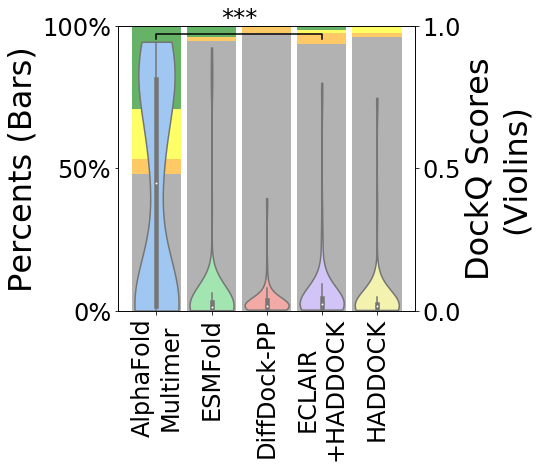


[DockQ stats]
  AlphaFold
Multimer n=  79, mean=0.412, median=0.450
  ESMFold            n=  79, mean=0.055, median=0.013
  DiffDock-PP        n=  79, mean=0.036, median=0.017
  ECLAIR
+HADDOCK    n=  79, mean=0.060, median=0.023
  HADDOCK            n=  79, mean=0.047, median=0.017
--------------------------------------------------------------
[INFO] iRMSD: 78 complexes after common filtering
[p-value] AFM vs ECLAIR
+HADDOCK: 3.234e-04 (***)


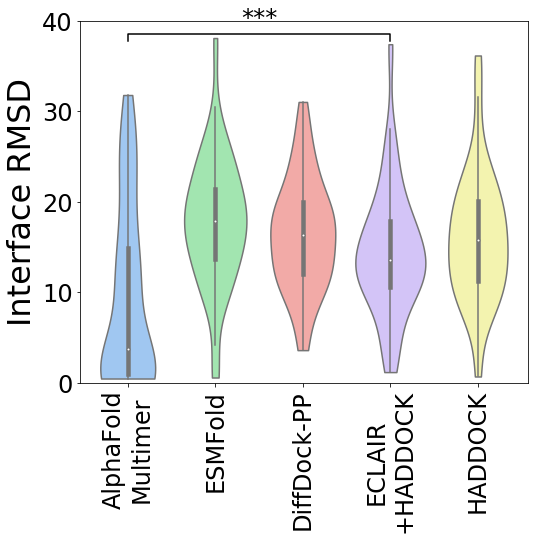


[iRMSD stats]
  AlphaFold
Multimer n=  78, mean=9.41, median=3.68
  ESMFold            n=  78, mean=17.83, median=17.88
  DiffDock-PP        n=  78, mean=16.39, median=16.35
  ECLAIR
+HADDOCK    n=  78, mean=14.47, median=13.56
  HADDOCK            n=  78, mean=16.10, median=15.80
--------------------------------------------------------------
[INFO] lRMSD: 76 complexes after common filtering
[p-value] AFM vs ECLAIR
+HADDOCK: 7.315e-05 (***)


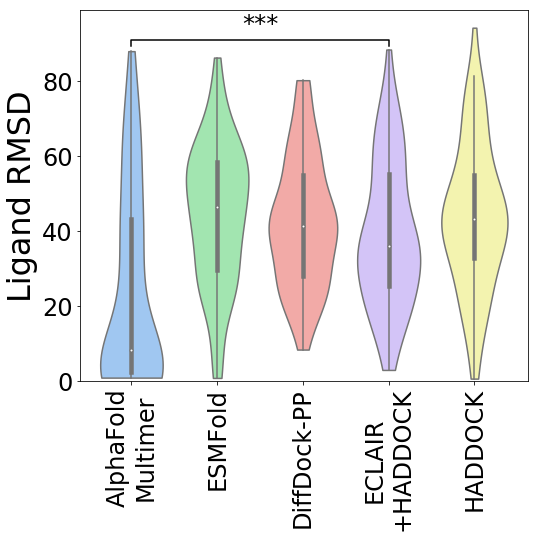


[lRMSD stats]
  AlphaFold
Multimer n=  76, mean=23.89, median=8.24
  ESMFold            n=  76, mean=44.67, median=46.31
  DiffDock-PP        n=  76, mean=42.28, median=41.21
  ECLAIR
+HADDOCK    n=  76, mean=39.14, median=36.06
  HADDOCK            n=  76, mean=43.82, median=43.28


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use("seaborn-pastel")

# ------------------------------------------------------------------
# Config
# ------------------------------------------------------------------
RES_HH_PATH = "Fig1A-C/Intraspecies_whole_structure_evaluation_AFM_all.txt"
RES_VH_PATH = "Fig1A-C/Interspecies_whole_structure_evaluation_addDDPP_bound_0.4_noFailed.txt"

GROUP_LABELS = [
    "AlphaFold\nMultimer",
    "ESMFold",
    "DiffDock-PP",
    "ECLAIR\n+HADDOCK",
    "HADDOCK",
]
METHOD_KEYS = ["AFM", "ESM", "DD", "GD", "RD"]

DOCKQ_COLS = {
    "AFM": "DockQ_AFM",
    "ESM": "DockQ_ESM",
    "DD": "DockQ_DD",
    "GD": "DockQ_GD",
    "RD": "DockQ_RD",
}
IRMSD_COLS = {
    "AFM": "iRMSD_AFM",
    "ESM": "iRMSD_ESM",
    "DD": "iRMSD_DD",
    "GD": "iRMSD_GD",
    "RD": "iRMSD_RD",
}
LRMSD_COLS = {
    "AFM": "lRMSD_AFM",
    "ESM": "lRMSD_ESM",
    "DD": "lRMSD_DD",
    "GD": "lRMSD_GD",
    "RD": "lRMSD_RD",
}

S_CUT = 0.0
SEL_DATE = 2       # 0 unseen, 1 seen, 2 all
GET_COMMON = True  # use complexes with valid values for all methods

FONT1 = 24
FONT2 = 32
plt.rcParams.update({"font.size": FONT1})


# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------
def add_stat_pval(ax, data, crit="lowest", labels=None):
    """
    Compare AFM (index 0) to the best other method (lowest or largest mean).
    Draw a bracket on 'ax' and print the p-value.
    """
    base = data[0]
    if len(data) <= 1:
        return

    means = [np.mean(d) for d in data[1:]]
    idx_other = np.argmin(means) + 1 if crit == "lowest" else np.argmax(means) + 1
    other = data[idx_other]

    stat, p_val = stats.ttest_ind(base, other, equal_var=False)
    y_coord = max(max(base), max(other))

    x1, x2 = 0, idx_other
    h1, h2, h3 = 1.01, 1.03, 1.04

    if p_val <= 0.001:
        sig = "***"
    elif p_val <= 0.01:
        sig = "**"
    elif p_val <= 0.05:
        sig = "*"
    else:
        sig = "ns"

    ax.plot([x1, x1, x2, x2],
            [y_coord * h1, y_coord * h2, y_coord * h2, y_coord * h1],
            lw=1.5, c="k")
    ax.text((x1 + x2) / 2, y_coord * h3, sig,
            ha="center", va="bottom", fontsize=FONT1)

    if labels is not None:
        print(f"[p-value] AFM vs {labels[idx_other]}: {p_val:.3e} ({sig})")


def select_interspecies_subset(res_vh, s_cut=0.0, sel_date=2):
    base = res_vh[
        (res_vh["NumResProt1"] >= 20)
        & (res_vh["NumResProt2"] >= 20)
        & (res_vh["AFM_Score"] >= s_cut)
    ]
    if sel_date == 0:
        return base[base["Date_after_train"]]
    elif sel_date == 1:
        return base[~base["Date_after_train"]]
    else:
        return base


def get_metric_arrays(res2, col_map, max_value=None, get_common=True):
    """
    Return {method: np.array(values)} with >0 and (< max_value if given).
    If get_common=True, restrict to complexes with valid values for all methods.
    """
    conds = {}
    for m, col in col_map.items():
        cond = res2[col] > 0
        if max_value is not None:
            cond &= res2[col] < max_value
        conds[m] = cond

    if get_common:
        common_mask = np.logical_and.reduce(list(conds.values()))
        print(f"[INFO] {list(col_map.values())[0].split('_')[0]}: "
              f"{common_mask.sum()} complexes after common filtering")
        return {m: res2.loc[common_mask, col].values for m, col in col_map.items()}
    else:
        return {m: res2.loc[conds[m], col].values for m, col in col_map.items()}


# ------------------------------------------------------------------
# Load data (intra file is loaded for completeness; not used directly here)
# ------------------------------------------------------------------
res_HH = pd.read_csv(RES_HH_PATH, sep="\t")
res_VH = pd.read_csv(RES_VH_PATH, sep="\t")
res2 = select_interspecies_subset(res_VH, s_cut=S_CUT, sel_date=SEL_DATE)

print(f"[INFO] Selected interspecies complexes: {res2.shape[0]}")

# ------------------------------------------------------------------
# DockQ (Fig. 1A)
# ------------------------------------------------------------------
dockq_data = get_metric_arrays(res2, DOCKQ_COLS, max_value=None, get_common=GET_COMMON)
dockq_ordered = [dockq_data[m] for m in METHOD_KEYS]

def _dockq_fractions(arr):
    n = len(arr)
    return np.array([
        (arr < 0.23).sum() / n,
        ((arr >= 0.23) & (arr < 0.49)).sum() / n,
        ((arr >= 0.49) & (arr < 0.8)).sum() / n,
        (arr >= 0.8).sum() / n,
    ])

fractions = {m: _dockq_fractions(dockq_data[m]) for m in METHOD_KEYS}

vals1 = [fractions[m][0] for m in METHOD_KEYS]  # incorrect
vals2 = [fractions[m][1] for m in METHOD_KEYS]  # acceptable
vals3 = [fractions[m][2] for m in METHOD_KEYS]  # medium
vals4 = [fractions[m][3] for m in METHOD_KEYS]  # high

fig, ax = plt.subplots(figsize=(8,7))
x = np.arange(len(GROUP_LABELS))

ax.bar(x, vals1, label="Incorrect", color="gray", width=0.9, alpha=0.6)
ax.bar(x, vals2, bottom=vals1, label="Acceptable", color="orange", width=0.9, alpha=0.6)
ax.bar(x, vals3, bottom=np.add(vals1, vals2), label="Medium", color="yellow", width=0.9, alpha=0.6)
ax.bar(x, vals4, bottom=np.add(np.add(vals1, vals2), vals3),
       label="High", color="green", width=0.9, alpha=0.6)

ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["0%", "50%", "100%"])
ax.set_ylabel("Percents (Bars)", fontsize=FONT2)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_LABELS, rotation=90)

ax2 = ax.twinx()
sns.violinplot(data=[list(arr) for arr in dockq_ordered],
               ax=ax2, scale="width", cut=0)
ax2.set_xticks(x)
ax2.set_xticklabels(GROUP_LABELS, rotation=90)
ax2.set_ylabel("DockQ Scores\n(Violins)", fontsize=FONT2)
ax2.set_ylim(0, 1)
ax2.set_yticks([0, 0.5, 1])

add_stat_pval(ax, dockq_ordered, crit="largest", labels=GROUP_LABELS)

fig.tight_layout()
fig.savefig("Fig1A-C/Fig1A.svg", format="svg", bbox_inches="tight")
plt.show()

print("\n[DockQ stats]")
for label, arr in zip(GROUP_LABELS, dockq_ordered):
    print(f"  {label:18s} n={len(arr):4d}, mean={arr.mean():.3f}, median={np.median(arr):.3f}")

print("--------------------------------------------------------------")
# ------------------------------------------------------------------
# iRMSD (Fig. 1B)
# ------------------------------------------------------------------
irmsd_data = get_metric_arrays(res2, IRMSD_COLS, max_value=50, get_common=GET_COMMON)
irmsd_ordered = [irmsd_data[m] for m in METHOD_KEYS]

fig, ax = plt.subplots(figsize=(8,8))
sns.violinplot(data=[list(arr) for arr in irmsd_ordered], ax=ax, cut=0)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_LABELS, rotation=90)
ax.set_ylabel("Interface RMSD", fontsize=FONT2)
ax.set_ylim(bottom=0)

add_stat_pval(ax, irmsd_ordered, crit="lowest", labels=GROUP_LABELS)

fig.tight_layout()
fig.savefig("Fig1A-C/Fig1B.svg", format="svg", bbox_inches="tight")
plt.show()

print("\n[iRMSD stats]")
for label, arr in zip(GROUP_LABELS, irmsd_ordered):
    print(f"  {label:18s} n={len(arr):4d}, mean={arr.mean():.2f}, median={np.median(arr):.2f}")

print("--------------------------------------------------------------")
# ------------------------------------------------------------------
# lRMSD (Fig. 1C)
# ------------------------------------------------------------------
lrmsd_data = get_metric_arrays(res2, LRMSD_COLS, max_value=100, get_common=GET_COMMON)
lrmsd_ordered = [lrmsd_data[m] for m in METHOD_KEYS]

fig, ax = plt.subplots(figsize=(8,8))
sns.violinplot(data=[list(arr) for arr in lrmsd_ordered], ax=ax, cut=0)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_LABELS, rotation=90)
ax.set_ylabel("Ligand RMSD", fontsize=FONT2)
ax.set_ylim(bottom=0)

add_stat_pval(ax, lrmsd_ordered, crit="lowest", labels=GROUP_LABELS)

fig.tight_layout()
fig.savefig("Fig1A-C/Fig1C.svg", format="svg", bbox_inches="tight")
plt.show()

print("\n[lRMSD stats]")
for label, arr in zip(GROUP_LABELS, lrmsd_ordered):
    print(f"  {label:18s} n={len(arr):4d}, mean={arr.mean():.2f}, median={np.median(arr):.2f}")
